# Градиентный бустинг над решающими деревьями

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss

1. Загрузите выборку из файла gbm-data.csv

In [14]:
data = pd.read_csv('gbm-data.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

2. Обучите GradientBoostingClassifier

      Iter       Train Loss   Remaining Time 
         1           1.0190            8.63s
         2           0.9192            8.94s
         3           0.8272            9.53s
         4           0.7834            9.38s
         5           0.7109            9.34s
         6           0.6368            9.31s
         7           0.5797            8.83s
         8           0.5610            9.29s
         9           0.5185            9.38s
        10           0.4984            9.31s
        20           0.1999            9.05s
        30           0.1313            8.52s
        40           0.0790            7.98s
        50           0.0511            7.66s
        60           0.0352            7.29s
        70           0.0245            7.04s
        80           0.0162            6.71s
        90           0.0114            6.25s
       100           0.0077            5.84s
       200           0.0002            2.16s
      Iter       Train Loss   Remaining Time 
        

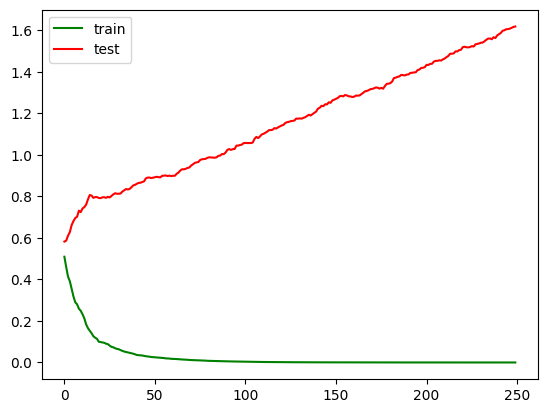

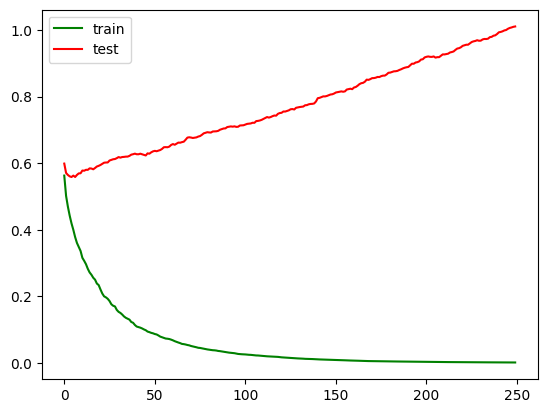

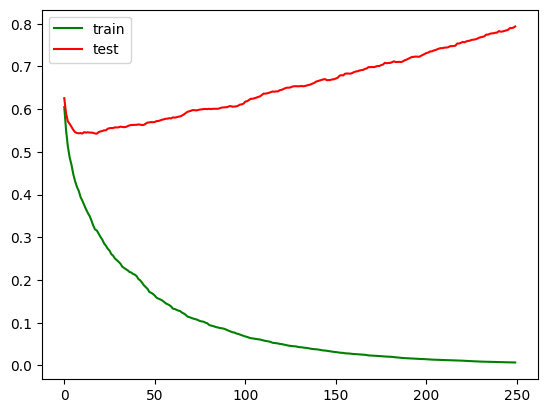

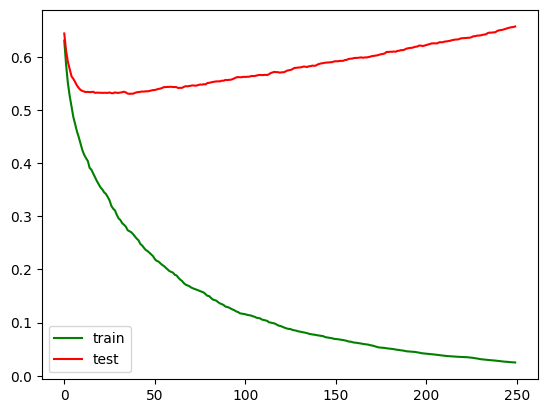

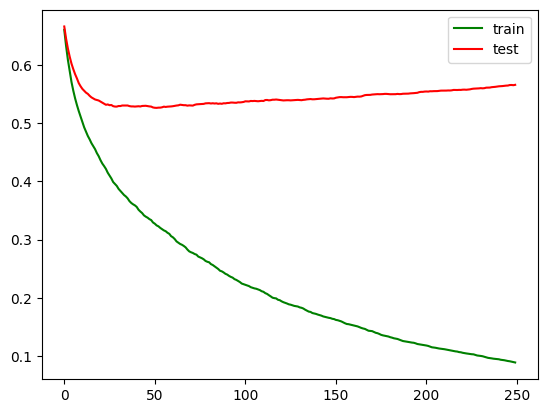

In [15]:
for learning_rate in [1.0, 0.5, 0.3, 0.2, 0.1]:
    model = GradientBoostingClassifier(n_estimators=250, verbose=True, random_state=241, learning_rate=learning_rate)
    model.fit(X_train, y_train)
    scores_train = []
    for y_pred in model.staged_decision_function(X_train):
        y_p = 1 / (1 + np.exp(-y_pred))
        scores_train.append(log_loss(y_train, y_p))
    scores_test = []
    for y_pred in model.staged_decision_function(X_test):
        y_p = 1 / (1 + np.exp(-y_pred))
        scores_test.append(log_loss(y_test, y_p))
    if learning_rate == 0.2:
        score4 = scores_test
    plt.figure()
    plt.plot(scores_train, 'g')
    plt.plot(scores_test, 'r')
    plt.legend(['train', 'test'])

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации

In [16]:
print('overfitting')

overfitting


4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate =0.2.

In [19]:
score = pd.Series(score4)
print(round(score.min(), 2), score.idxmin() + 1)

0.53 37


5. На этих же данных обучите RandomForestClassifier

In [24]:
model = RandomForestClassifier(n_estimators=37, random_state=241)
model.fit(X_train, y_train)
print(log_loss(y_test, model.predict_proba(X_test)))

0.5410941951182815
